In [2]:
!git clone https://github.com/TalhaIslam1729/music-generation-unsupervised.git
%cd music-generation-unsupervised

Cloning into 'music-generation-unsupervised'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 37 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 36.52 KiB | 1.92 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/kaggle/working/music-generation-unsupervised


In [3]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 55.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.3 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=b67cf2803d33419abbb84373ef4a561604d84a5f4efeac6e51cbe2ccf4c21d40
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [4]:
!pip install --upgrade pip
!pip install torch torchaudio librosa transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.9 MB/s eta 0:00:0000:010:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [5]:
!apt-get update -y
!apt-get install ffmpeg -y

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,294 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,915 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [

In [6]:
!ls

notebooks  README.md  requirements.txt	src


In [46]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from src.config import *

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_MIDI_DIR = DATA_DIR / "raw_midi"
PROCESSED_DIR = DATA_DIR / "processed"
TRAIN_TEST_SPLIT_DIR = DATA_DIR / "train_test_split"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
GENERATED_MIDI_DIR = OUTPUT_DIR / "generated_midis"
PLOTS_DIR = OUTPUT_DIR / "plots"

# create directories
for d in [
    DATA_DIR,
    RAW_MIDI_DIR,
    PROCESSED_DIR,
    TRAIN_TEST_SPLIT_DIR,
    OUTPUT_DIR,
    GENERATED_MIDI_DIR,
    PLOTS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_MIDI_DIR:", RAW_MIDI_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

PROJECT_ROOT: /kaggle/working/music-generation-unsupervised
RAW_MIDI_DIR: /kaggle/working/music-generation-unsupervised/data/raw_midi
PROCESSED_DIR: /kaggle/working/music-generation-unsupervised/data/processed


In [47]:
from pathlib import Path
import shutil
from tqdm.auto import tqdm

DATA_DIR = Path("./data")
RAW_MIDI_DIR = DATA_DIR / "raw_midi"

RAW_MIDI_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("RAW_MIDI_DIR:", RAW_MIDI_DIR.resolve())


DATA_DIR: /kaggle/working/music-generation-unsupervised/data
RAW_MIDI_DIR: /kaggle/working/music-generation-unsupervised/data/raw_midi


In [48]:
KAGGLE_DATASET_PATH = Path("/kaggle/input/datasets/talhaisl4m/midi-genre-datase")

midi_files = []
for ext in ["*.mid", "*.MID", "*.midi", "*.MIDI"]:
    midi_files.extend(KAGGLE_DATASET_PATH.rglob(ext))

print("Found MIDI files:", len(midi_files))

if len(midi_files) == 0:
    print("\nNo MIDI files found. Listing dataset contents for debugging:")
    for p in list(KAGGLE_DATASET_PATH.rglob("*"))[:30]:
        print(" ", p)

copied = 0
errors = 0

for midi_path in tqdm(midi_files):
    rel = midi_path.relative_to(KAGGLE_DATASET_PATH)
    safe_name = "_".join(rel.parts)
    target = RAW_MIDI_DIR / safe_name

    try:
        shutil.copy2(midi_path, target)
        copied += 1
    except Exception as e:
        print("Error:", e)
        errors += 1

print(f"\nCopied: {copied} | Errors: {errors}")
print("Files in raw_midi:", len(list(RAW_MIDI_DIR.glob("*"))))


Found MIDI files: 0

⚠️  No MIDI files found. Listing dataset contents for debugging:
  /kaggle/input/datasets/talhaisl4m/midi-genre-datase/raw_midi
  /kaggle/input/datasets/talhaisl4m/midi-genre-datase/raw_midi/maestro-v3.0.0.csv


0it [00:00, ?it/s]


Copied: 0 | Errors: 0
Files in raw_midi: 0


In [20]:
from src.preprocessing.midi_parser import MIDIParser

parser = MIDIParser(root_dir=RAW_MIDI_DIR)

dataset = parser.build_metadata()

dataset_df = pd.DataFrame(dataset)

dataset_df.head()


Found 0 MIDI files



Parsing MIDI Files: 0it [00:00, ?it/s]


""


In [21]:
metadata_path = PROCESSED_DIR / "parsed_metadata.csv"

dataset_df.to_csv(metadata_path, index=False)

print("Saved metadata:", metadata_path)
print("Total files:", len(dataset_df))

Saved metadata: /kaggle/working/music-generation-unsupervised/data/processed/parsed_metadata.csv
Total files: 0


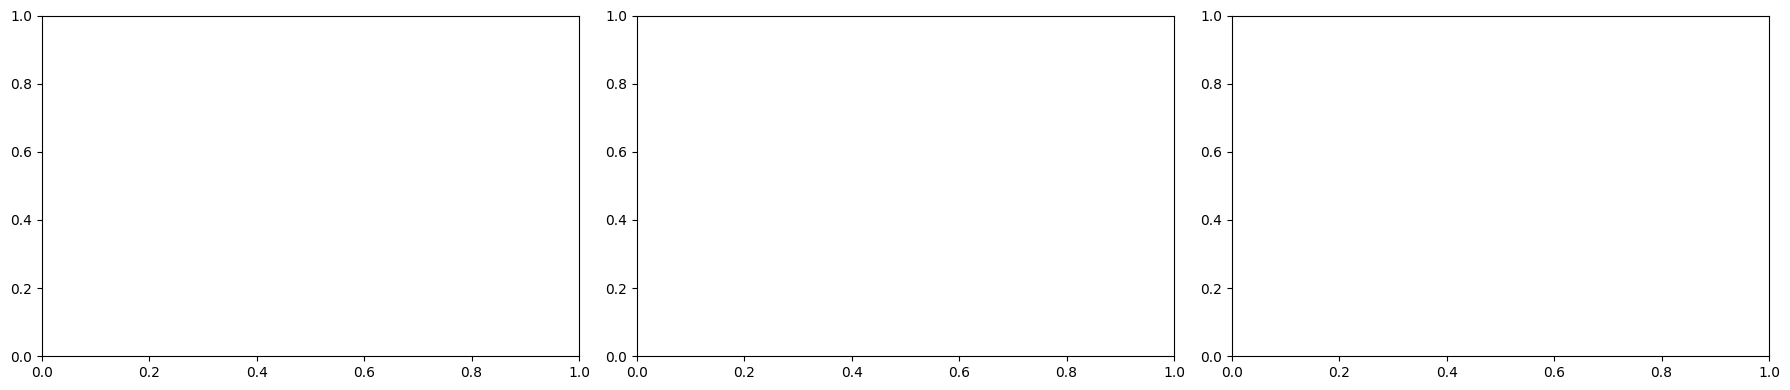

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# duration distribution
if "duration" in dataset_df.columns:
    axes[0].hist(dataset_df["duration"], bins=50)
    axes[0].set_title("Duration Distribution")

# tempo distribution
if "tempo" in dataset_df.columns:
    axes[1].hist(dataset_df["tempo"], bins=50)
    axes[1].set_title("Tempo Distribution")

# instrument count
if "instrument_count" in dataset_df.columns:
    axes[2].hist(dataset_df["instrument_count"], bins=20)
    axes[2].set_title("Instrument Count")

plt.tight_layout()
plt.show()

In [23]:
from sklearn.model_selection import train_test_split

all_files = dataset_df["path"].tolist()

train_files, temp_files = train_test_split(
    all_files,
    test_size=0.2,
    random_state=42
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.5,
    random_state=42
)

print("Train:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

KeyError: 'path'

In [24]:
np.save(TRAIN_TEST_SPLIT_DIR / "train_files.npy", train_files)
np.save(TRAIN_TEST_SPLIT_DIR / "val_files.npy", val_files)
np.save(TRAIN_TEST_SPLIT_DIR / "test_files.npy", test_files)

print("Saved split file lists")

NameError: name 'train_files' is not defined

In [25]:
from src.preprocessing.piano_roll import build_piano_roll_dataset

train_dataset = build_piano_roll_dataset(
    train_files,
    save_path=TRAIN_TEST_SPLIT_DIR / "train.npy"
)

val_dataset = build_piano_roll_dataset(
    val_files,
    save_path=TRAIN_TEST_SPLIT_DIR / "val.npy"
)

test_dataset = build_piano_roll_dataset(
    test_files,
    save_path=TRAIN_TEST_SPLIT_DIR / "test.npy"
)

print("Train shape:", train_dataset.shape)
print("Val shape:", val_dataset.shape)
print("Test shape:", test_dataset.shape)

NameError: name 'train_files' is not defined

In [26]:
train = np.load(TRAIN_TEST_SPLIT_DIR / "train.npy")

print(train.shape)
print(train.dtype)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/music-generation-unsupervised/data/train_test_split/train.npy'

In [27]:
from src.preprocessing.piano_roll import piano_roll_to_midi

sample = train_dataset[0]

sample_output = GENERATED_MIDI_DIR / "sample.mid"

piano_roll_to_midi(
    sample,
    output_path=sample_output
)

print("Saved sample MIDI:", sample_output)

NameError: name 'train_dataset' is not defined

In [28]:
print("========== DATASET SUMMARY ==========")

print("Raw MIDI Files:")
print(len(list(RAW_MIDI_DIR.glob("*"))))

print("\nTrain Dataset:")
print(train_dataset.shape)

print("\nValidation Dataset:")
print(val_dataset.shape)

print("\nTest Dataset:")
print(test_dataset.shape)

print("\nOutputs Saved To:")
print(TRAIN_TEST_SPLIT_DIR)

========== DATASET SUMMARY ==========
Raw MIDI Files:
0

Train Dataset:


NameError: name 'train_dataset' is not defined